In [193]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
import re

# These settings are used to be trained in kaggle T4 GPU environment
BATCH_SIZE = 16 #16
IMG_SIZE = (256, 256)
RESIZED_IMG_SIZE = (128, 128) # (96, 96)
LEARNING_RATE=5e-5 # 5e-5
USE_SMALL_DATASET = True # change to false if you want to use whole dataset
SMALL_DATASET_SIZE= 800 # 625
LOSS = tf.keras.losses.SparseCategoricalCrossentropy()
OPTIMIZER = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
METRICS = ['accuracy', ]
EPOCHS = 100

TRAIN_DIR = "/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
VAL_DIR = "/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"
TEST_DIR = "/kaggle/input/new-plant-diseases-dataset/test/test"

# Verify that tf is using GPU
if tf.config.list_physical_devices('GPU'):
    print("Using GPU")
else:
    print("Using CPU")

Using GPU


In [194]:
# Setup train, val dataset
train_ds = tf.keras.utils.image_dataset_from_directory(directory=TRAIN_DIR,
                                                       labels="inferred",
                                                       seed=123,
                                                       image_size=(IMG_SIZE),
                                                       batch_size=BATCH_SIZE,
                                                       shuffle=True)

val_ds = tf.keras.utils.image_dataset_from_directory(directory=VAL_DIR,
                                                     labels="inferred",
                                                     seed=123,
                                                     image_size=(IMG_SIZE),
                                                     batch_size=BATCH_SIZE,
                                                     )

# Use mixed precision to reduce size of dataset
policy = tf.keras.mixed_precision.Policy('mixed_float16')
tf.keras.mixed_precision.set_global_policy(policy)

print("Datasets loaded!")

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
Datasets loaded!


In [195]:
# Clean train dataset class names
CLEANED_TRAIN_CLASS_NAMES = {}
dict_idx = 0

# filler words to be removed
FILLERS = ['including', 'maize', 'Citrus', 'Greening', 'Two-spotted']

for original_label in train_ds.class_names:
    # Capitalise letter followed by underscore
    label = re.sub(r"_+(\w)", lambda m: m.group(1).upper(), original_label)

    # Remove brackets, commas, underscores
    label = re.sub(r"[(),]", "", label)

    # Remove remaining underscores and collapse multiple spaces
    label = re.sub(r"_+", "", label)
    label = re.sub(r"\s+", " ", label).strip()

    # Remove filler words
    for filler in FILLERS:
        label = label.replace(filler, "")

    # Remove repeated names
    label = re.sub(r'([A-Z][a-z]*?)\1+', r'\1', label)
    
    CLEANED_TRAIN_CLASS_NAMES[label] = dict_idx
    dict_idx += 1

print(CLEANED_TRAIN_CLASS_NAMES)

{'AppleScab': 0, 'AppleBlackRot': 1, 'AppleCedarAppleRust': 2, 'AppleHealthy': 3, 'BlueberryHealthy': 4, 'CherrySourPowderyMildew': 5, 'CherrySourHealthy': 6, 'CornCercosporaLeafSpot GrayLeafSpot': 7, 'CornCommonRust': 8, 'CornNorthernLeafBlight': 9, 'CornHealthy': 10, 'GrapeBlackRot': 11, 'GrapeEscaBlackMeasles': 12, 'GrapeLeafBlightIsariopsisLeafSpot': 13, 'GrapeHealthy': 14, 'OrangeHaunglongbing': 15, 'PeachBacterialSpot': 16, 'PeachHealthy': 17, 'PepperBellBacterialSpot': 18, 'PepperBellHealthy': 19, 'PotatoEarlyBlight': 20, 'PotatoLateBlight': 21, 'PotatoHealthy': 22, 'RaspberryHealthy': 23, 'SoybeanHealthy': 24, 'SquashPowderyMildew': 25, 'StrawberryLeafScorch': 26, 'StrawberryHealthy': 27, 'TomatoBacterialSpot': 28, 'TomatoEarlyBlight': 29, 'TomatoLateBlight': 30, 'TomatoLeafMold': 31, 'TomatoSeptoriaLeafSpot': 32, 'TomatoSpiderMites SpiderMite': 33, 'TomatoTargetSpot': 34, 'TomatoYellowLeafCurlVirus': 35, 'TomatoMosaicVirus': 36, 'TomatoHealthy': 37}


In [196]:
# Normalize the names
# Get file paths of every img in TEST_DIR
file_path = [os.path.join(TEST_DIR, f) for f in os.listdir(TEST_DIR) if f.endswith(".JPG")]

# extract labels from filenames
test_class_names = sorted(list(set([f.split('/')[-1].split('.')[0].rstrip('0123456789') for f in file_path])))

test_labels = [class_to_index[f.split('/')[-1].split('.')[0].rstrip('0123456789')] for f in file_path]

# make dict
CLEANED_TEST_CLASS_NAMES = {name: idx for idx, name in enumerate(test_class_names)}

# manually change it to match train 
CLEANED_TEST_CLASS_NAMES['AppleScab'] = 0
CLEANED_TEST_CLASS_NAMES['AppleCedarRust'] = 2
CLEANED_TEST_CLASS_NAMES['CornCommonRust'] = 8
CLEANED_TEST_CLASS_NAMES['PotatoEarlyBlight'] = 20
CLEANED_TEST_CLASS_NAMES['PotatoHealthy'] = 21
CLEANED_TEST_CLASS_NAMES['TomatoEarlyBlight'] = 29
CLEANED_TEST_CLASS_NAMES['TomatoHealthy'] = 27
CLEANED_TEST_CLASS_NAMES['TomatoYellowCurlVirus'] = 35

print(test_labels)

[5, 7, 7, 4, 7, 3, 7, 5, 2, 1, 5, 6, 2, 3, 5, 7, 2, 5, 0, 6, 1, 6, 1, 0, 4, 7, 3, 0, 3, 5, 0, 3, 6]


In [197]:
test_ds = tf.keras.utils.image_dataset_from_directory(directory=TEST_DIR,
                                                      labels=test_labels,
                                                     batch_size=BATCH_SIZE)

Found 33 files belonging to 8 classes.


In [198]:
# Model: Tiny-LiteNet, size of 1.2MB
# automatic tuning
AUTOTUNE = tf.data.AUTOTUNE

# Normalize the image from [0, 255] -> [0, 1]
# resize image from (256, 256) -> (96, 96) The paper uses (244,244)
normalization_layer = tf.keras.layers.Rescaling(1./255)
resize_layer = tf.keras.layers.Resizing(RESIZED_IMG_SIZE[0], RESIZED_IMG_SIZE[1])

# Dataset.prefetch to GPU, lets cpu prepare batches while GPU is training
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Text(0.5, 1.0, 'PotatoEarlyBlight')

<Figure size 800x400 with 0 Axes>

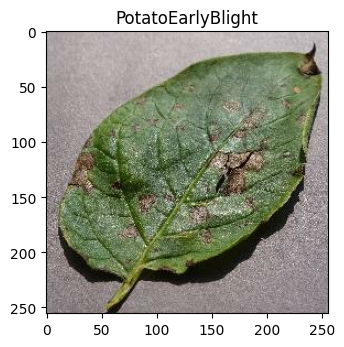

In [199]:
# load img from dataset
plt.figure(figsize=(8, 4))
for images, labels in train_ds.take(1):
    original_img = images[0]
    original_label = labels[0].numpy()
    break

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(original_img.numpy().astype("uint8"))
plt.title(list(CLEANED_TRAIN_CLASS_NAMES.keys())[list(CLEANED_TRAIN_CLASS_NAMES.values()).index(original_label)])

In [200]:
if USE_SMALL_DATASET:
  # Use smaller dataset to avoid crashing in google colab
  train_ds = train_ds.take(SMALL_DATASET_SIZE)
  val_ds = val_ds.take(SMALL_DATASET_SIZE)

# Show dataset size (in batches)
print(f"train_ds size: {tf.data.experimental.cardinality(train_ds) * BATCH_SIZE}")
print(f"val_ds size: {tf.data.experimental.cardinality(val_ds) * BATCH_SIZE}")
print(f"test_ds size: {tf.data.experimental.cardinality(test_ds) * BATCH_SIZE}")

train_ds size: 12800
val_ds size: 12800
test_ds size: 48


In [201]:
# norm and resize in model to use GPU instead of CPU
def se_depthwise_block():
  return [
      tf.keras.layers.DepthwiseConv2D(kernel_size=3),
      tf.keras.layers.BatchNormalization(),
      tf.keras.layers.Activation('relu'),
      tf.keras.layers.SeparableConv2D(filters=128, kernel_size=1),
      tf.keras.layers.BatchNormalization(),
      tf.keras.layers.Activation('relu'),
      tf.keras.layers.MaxPool2D()
  ]


model = tf.keras.Sequential([
    resize_layer,
    normalization_layer,
    *se_depthwise_block(),
    *se_depthwise_block(),
    *se_depthwise_block(),
    *se_depthwise_block(),
    *se_depthwise_block(),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(1000, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')# softmax for multiclass classification
])
model

<Sequential name=sequential, built=False>

In [202]:
# clear prev session before building model
tf.keras.backend.clear_session()

# compile model
model.compile(optimizer=OPTIMIZER,
              loss=LOSS,
              metrics=METRICS)

In [203]:
# implement early stopping, prevent overfitting
callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    mode='min',
    verbose=1
)

In [204]:
# Train the model
history = model.fit(train_ds,
          validation_data=val_ds,
          batch_size=BATCH_SIZE,
          epochs=EPOCHS,
        callbacks=[callback],
        verbose=1
                   )

Epoch 1/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 38s 23ms/step - accuracy: 0.0844 - loss: 3.4874 - val_accuracy: 0.1640 - val_loss: 3.1010
Epoch 2/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.2566 - loss: 2.7984 - val_accuracy: 0.3766 - val_loss: 2.3318
Epoch 3/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.3609 - loss: 2.3560 - val_accuracy: 0.4589 - val_loss: 1.9537
Epoch 4/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.4331 - loss: 2.0109 - val_accuracy: 0.5236 - val_loss: 1.6864
Epoch 5/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.4855 - loss: 1.7973 - val_accuracy: 0.5670 - val_loss: 1.5086
Epoch 6/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.5408 - loss: 1.6167 - val_accuracy: 0.5965 - val_loss: 1.3932
Epoch 7/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.5582 - loss: 1.4968 - val_accuracy: 0.6230 - val_loss: 1.2997
Epoch 8/100
800/800 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.5941 - loss: 1

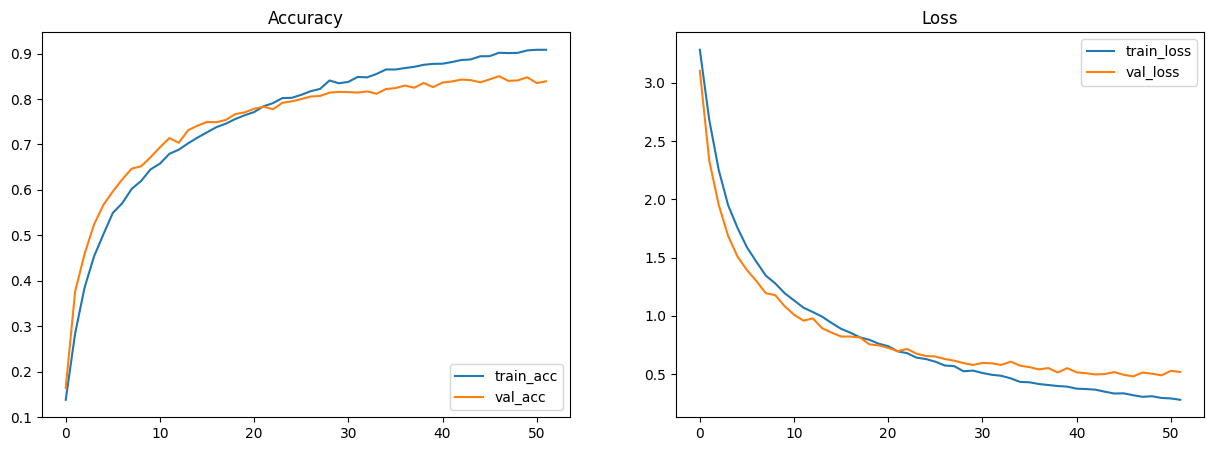

In [208]:
# Plot graph of train and validation to see if overfitting/underfitting
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = list(range(len(train_loss)))

fig, ax = plt.subplots(1,2, figsize=(15,5))

ax[0].plot(epochs, train_acc, label='train_acc')
ax[0].plot(epochs, val_acc, label='val_acc')
ax[0].set_title('Accuracy')
ax[0].legend(loc="lower right")

ax[1].plot(epochs, train_loss, label='train_loss')
ax[1].plot(epochs, val_loss, label='val_loss')
ax[1].set_title('Loss')
ax[1].legend(loc="upper right")

In [209]:
# save model
model.save("/kaggle/working/tinylite-net.keras")

# save model weights
model.save_weights('/kaggle/working/tinylite-net-weights.weights.h5')

In [221]:
try:
    loaded_model = tf.keras.models.load_model("/kaggle/working/tinylite-net.keras")

    for images, label in test_ds:
        prediction = loaded_model.predict(img)

        
except OSError:
    print("Model not found")

ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("Cast:0", shape=(32, 256, 3), dtype=float16). Expected shape (None, 256, 256, 3), but input has incompatible shape (32, 256, 3)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 256, 3), dtype=float16)
  • training=False
  • mask=None

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Prediction: Tomato___Early_blight
True: TomatoHealthy
{'AppleCedarRust': 0, 'AppleScab': 1, 'CornCommonRust': 2, 'PotatoEarlyBlight': 3, 'PotatoHealthy': 4, 'TomatoEarlyBlight': 5, 'TomatoHealthy': 6, 'TomatoYellowCurlVirus': 7}


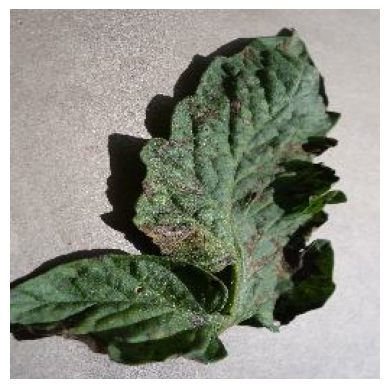

In [210]:
 # Make prediction
for image, labels in test_ds.take(1):
  img = image[0]
  label = labels[0]

  plt.imshow(np.squeeze(img.numpy().astype("uint8")))
  plt.axis("off")

  img_batch = tf.expand_dims(img, axis=0)

  prediction = model.predict(img_batch)

  predicted_label = np.argmax(prediction)
  print(f"Prediction: {CLASS_NAMES[predicted_label]}")
  print(f"True: {class_names[label]}")
  print(class_to_index)


In [ ]:
# Convert model to tflite